# Cloning quasars (time to get your hands dirty).

Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey.
The Sloan Digital Sky Survey or SDSS is a major multi-spectral imaging and spectroscopic redshift survey using a dedicated 2.5-m wide-angle optical telescope at Apache Point Observatory in New Mexico, United States. Operations started in 1998.
In phase 1, SDSS has released photometry data 357 million (!!!) unique sources and 1.6 million spectra. In phase 2, SDSS observed the same patch of the sky many times ("time domain astronomy", and now we're going to have LSST!)

In [7]:
import matplotlib.pyplot as plt
import astropy
import numpy as np
astropy.cosmology.Planck18
from urllib.request import urlretrieve

In [12]:
urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", './dr7qso.dat')

('./dr7qso.dat', <http.client.HTTPMessage at 0x2308b2f56d0>)

In [8]:
# There are 80 header lines, skip them. The redshift is in column 3. 
#Careful that there's another z feature, but that refers to the SDSS z filter, not the redshift
z= np.loadtxt('dr7qso.dat',skiprows=80, usecols=3)

Text(0.5, 0, 'z')

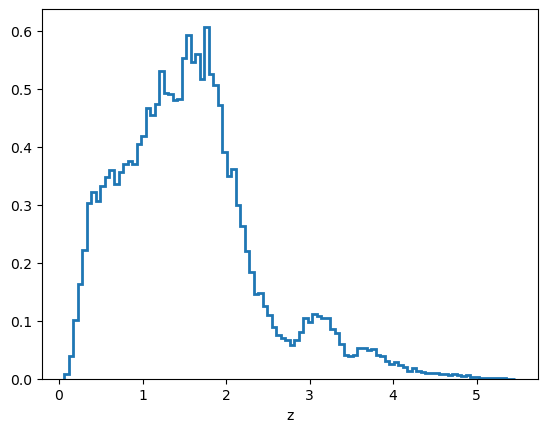

In [9]:
plt.hist(z,bins=100,density=True,histtype='step',lw=2);
plt.xlabel('z')

- Upsample this distribution in hopefully two ways (but at least one of them), using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)
- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation?
(Hint: It shouldn't. But why?)

# Rejection sampling

In [22]:
hist, bin_edges = np.histogram(z, bins=50, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

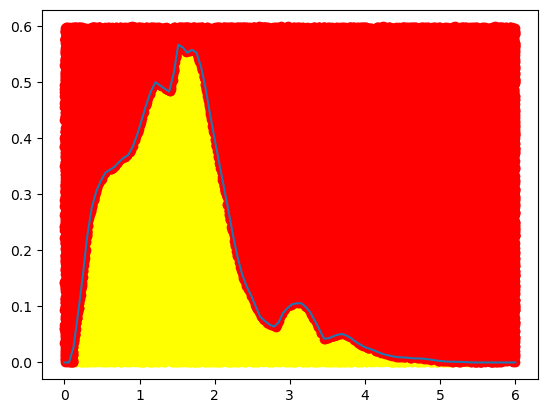

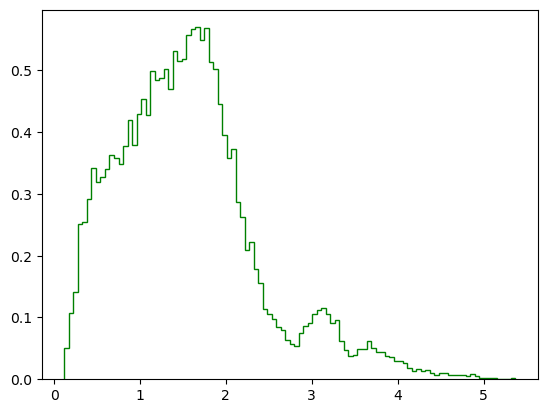

In [58]:
f = lambda x: np.interp(x, bin_centers, hist, left=0, right=0) 

N=100000

xg = np.linspace(0,6,100)

plt.plot(xg,f(xg))


ymax = 0.6
x = np.random.uniform(0,6,N)
y = np.random.uniform(0,ymax,N)


plt.scatter(x[y<f(x)],y[y<f(x)],c='yellow')
plt.scatter(x[y>f(x)],y[y>f(x)],c='red')

plt.show()
goodpoints = x[y<f(x)]


plt.hist(goodpoints,bins=100,density=True,histtype='step',color='green');

# Inverse Transform

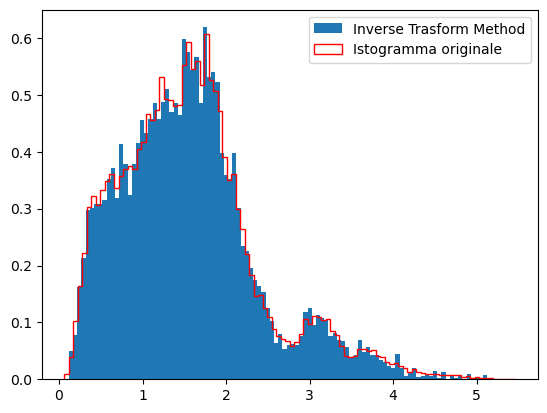

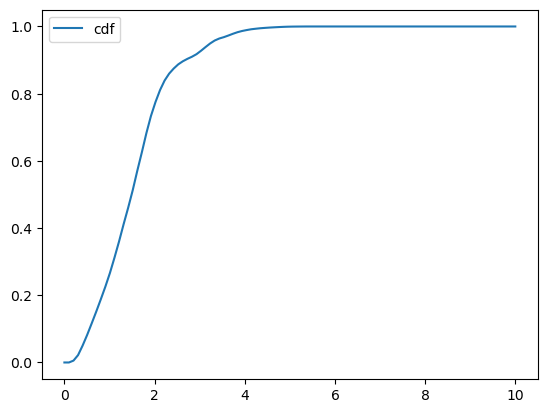

In [56]:
x=np.linspace(0,10,100)

counts, bin_edges = np.histogram(z, bins=100)
cdf_vals = np.cumsum(counts)
cdf_vals = cdf_vals / cdf_vals[-1]   #normalizzato la cdf

def cdf(x):
    return np.interp(x, bin_edges[1:], cdf_vals, left=0.0, right=1.0) #qui ho semplicemente interpolato la cdf 

eps = np.random.uniform(0,1,10000)
# Using a vanilla root finder, which solves for cdf(h)=eps i.e. finds the zero of the function cdf(x)-eps
samples = [ scipy.optimize.brentq(lambda h: cdf(h)-e, 0, 6) for e in eps]


plt.hist(samples,bins=100, density=True, label = 'Inverse Trasform Method')
plt.hist(z, bins=100, density=True, histtype='step', color = 'red', label='Istogramma originale')
plt.legend()

plt.figure()
plt.plot(x, cdf(x), label = 'cdf')
plt.legend()

# Quasar distribution

What's the quasar distribution with redshift?